In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import glob

from src.parsers import HMParser, CotevParser
from src.resources import Aggregator, Generator, Load, Storage

In [2]:
# Data parsing

# EC data for non-renewable generators and batteries
data_ec = HMParser(file_path='/Users/ecgomes/DataspellProjects/pyecom/data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/population_731.csv',
                      driving_history_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/ev_driving_history_731.csv',
                      assigned_segments_path='/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/assigned_segments_731.csv',
                      parse_date_start='2019',
                      parse_date_end='2020')
data_ev.parse()

In [3]:
# UPAC Data load

data_upacs = {}
for i in glob.glob('/Users/ecgomes/Documents/PhD/UPAC data/upac*_pv.csv'):
    temp = pd.read_csv(i, index_col=0, parse_dates=True)
    temp = temp.resample('H').mean()

    # Need to divide by 1000 to convert from W to kW
    temp['pv'] = temp['pv'] / 1000
    temp['load'] = temp['load'] / 1000

    # Set any negative values to zero
    temp.loc[temp['pv'] < 0, 'pv'] = 0
    temp.loc[temp['load'] < 0, 'load'] = 0

    # We only want 2019 and 2020 data
    temp = temp.loc['2019':'2020']

    # Fill NaN values with zeros
    temp = temp.fillna(0)

    name = i.split('/')[-1].split('_')[0].split('upac')[1]

    data_upacs[name] = temp

In [4]:
# Train resource creation

def create_resources(upacs, ec, ev):
    """
    Create the resources for the training environment.
    return a list of resources.
    :param upacs: dict with the UPAC data
    :param ec: dict with the EC data
    :param ev: dict with the EV data
    """

    resources = []
    # Add generators (from pv column from the UPAC data)
    for i in range(len(upacs)):
        current_name = list(upacs.keys())[i]
        resources.append(Generator(
            name='ren_generator_' + current_name,
            value=np.zeros(upacs[current_name]['pv'].shape),
            lower_bound=np.zeros(upacs[current_name]['pv'].shape),
            upper_bound=upacs[current_name]['pv'].values,
            cost=ec.generator['cost_parameter_b'][0, 0] * np.ones(upacs[current_name].shape[0]),
            cost_nde=np.tile(ec.generator['cost_nde'][0], (int(upacs[current_name].shape[0] / 24))),
            is_renewable=True))

    # Add loads (from load column from the UPAC data)
    for i in range(len(upacs)):
        current_name = list(upacs.keys())[i]
        resources.append(Load(
            name='load_' + current_name,
            value=upacs[current_name]['load'],
            lower_bound=np.zeros(upacs[current_name].shape),
            upper_bound=upacs[current_name]['load'].values,
            cost=np.ones(upacs[current_name].shape[0]),
            cost_cut=np.tile(ec.load['cost_cut'][0], (int(upacs[current_name].shape[0] / 24))),
            cost_reduce=np.tile(ec.load['cost_reduce'][0], (int(upacs[current_name].shape[0] / 24))),
            cost_ens=np.tile(ec.load['cost_ens'][0], (int(upacs[current_name].shape[0] / 24)))))

    # Add storage (from the EC data)
    for i in range(ec.storage['p_charge_limit'].shape[0]):
        resources.append(Storage(
            name='storage_{:02d}'.format(i+1),
            value=ec.storage['initial_state'][i] * np.ones(upacs['02'].shape[0]),
            lower_bound=np.ones(upacs['02'].shape[0]) * ec.storage['energy_min_percentage'][i],
            upper_bound=(ec.storage['energy_capacity'][i] * np.ones(upacs['02'].shape[0])),
            cost=np.ones(upacs['02'].shape[0]) * 0,
            cost_discharge=np.tile(ec.storage['discharge_price'][i], (int(upacs['02'].shape[0] / 24))),
            cost_charge=np.tile(ec.storage['charge_price'][i], (int(upacs['02'].shape[0] / 24))),
            capacity_max=ec.storage['energy_capacity'][i],
            capacity_min=ec.storage['energy_min_percentage'][i],
            initial_charge=ec.storage['initial_state'][i],
            discharge_efficiency=ec.storage['discharge_efficiency'][i],
            discharge_max=np.tile(ec.storage['p_discharge_limit'][i], (int(upacs['02'].shape[0] / 24))),
            charge_efficiency=ec.storage['charge_efficiency'][i],
            charge_max=np.tile(ec.storage['p_charge_limit'][i], (int(upacs['02'].shape[0] / 24))),
            capital_cost=np.array([0.05250, 0.10500, 0.01575])))

    # Add vehicles (from the EV data)
    for i in np.arange(len(ev)):
        resources.append(ev[i])

    # Append Aggregator
    resources.append(Aggregator(
        name='aggregator',
        value=np.zeros(upacs['02'].shape[0]),
        lower_bound=np.zeros(upacs['02'].shape[0]),
        upper_bound=np.tile(ec.peers['import_contracted_p_max'][0, 0], (upacs['02'].shape[0])),
        cost=np.tile(ec.peers['buy_price'][0, 0], (upacs['02'].shape[0])),
        imports=np.zeros(upacs['02'].shape[0]),
        exports=np.zeros(upacs['02'].shape[0]),
        import_cost=np.tile(ec.peers['buy_price'][0], (int(upacs['02'].shape[0] / 24))), # * 100,
        export_cost=np.tile(ec.peers['sell_price'][0], (int(upacs['02'].shape[0] / 24))),
        import_max=np.tile(ec.peers['import_contracted_p_max'][0, 0], (int(upacs['02'].shape[0]))),
        export_max=np.tile(ec.peers['export_contracted_p_max'][0, 0], (int(upacs['02'].shape[0])))))

    return resources

In [6]:
# Create resources for the training environment

def iterate_resources(u, c, e, mode='daily'):

    temp = {}

    # Save first key of upac data
    first_key = list(u.keys())[0]

    if mode == 'daily':

        # Loop to iterate over days in the datasets
        for i in np.unique(u[first_key].index.date):
            # Create the resources for the training environment

            date = i.strftime('%Y-%m-%d')

            temp_u = {k: v.loc[date] for k, v in u.items()}
            temp_e = e.create_resources(e.population, e.trips_grid, e.assigned_segments, date)

            temp[date] = create_resources(upacs=temp_u,
                                          ec=c,
                                          ev=temp_e)

    elif mode == 'monthly':

        # Loop to iterate over months in the datasets
        # Need to be careful with different years
        unique_months = np.unique(data_upacs['02'].index.strftime('%Y-%m'))

        for i in unique_months:
            # Create the resources for the training environment
            date = i

            temp_u = {k: v.loc[date] for k, v in u.items()}
            temp_e = e.create_resources(e.population, e.trips_grid, e.assigned_segments, date)

            temp[date] = create_resources(upacs=temp_u,
                                          ec=c,
                                          ev=temp_e)

    elif mode == 'yearly':

        # Loop to iterate over years in the datasets
        unique_years = np.unique(data_upacs['02'].index.strftime('%Y'))

        for i in unique_years:
            # Create the resources for the training environment
            date = i

            temp_u = {k: v.loc[date] for k, v in u.items()}
            temp_e = e.create_resources(e.population, e.trips_grid, e.assigned_segments, date)

            temp[date] = create_resources(upacs=temp_u,
                                          ec=c,
                                          ev=temp_e)

    return temp

dataset_resources = iterate_resources(u=data_upacs, c=data_ec, e=data_ev, mode='monthly')

In [7]:
# Load the data

test_data = pd.DataFrame({})
for file in glob.glob('../priority_paper/*.csv'):
    data = pd.read_csv(file, index_col=0)
    name = file.split('/')[-1].split('.')[0]
    
    # Create index for data
    data.index = pd.date_range(start=name, periods=data.shape[0], freq='H')
    
    # Add data to the DataFrame
    test_data = pd.concat([test_data, data], axis=0)
    
# Sort the data
test_data = test_data.sort_index()

In [12]:
test_data.iloc[:1440]

,ren_generator_08,ren_generator_06,ren_generator_02,ren_generator_09,ren_generator_13,storage_01,storage_01_charge,storage_01_discharge,storage_02,storage_02_charge,...,ev_04,ev_04_charge,ev_04_discharge,ev_05,ev_05_charge,ev_05_discharge,imports,exports,energy_history,order_history
2019-01-01 00:00:00,0.0,0.001306,0.0,0.000010,0.0,0.895000,5.000000,0.0,0.83840,4.0,...,0.876235,5.7600,0.0,0.827692,2.1600,0.0,33.751656,0.0,-33.751656,"['ren_generator_09', 'ren_generator_08', 'ren_..."
2019-01-01 01:00:00,0.0,0.001228,0.0,0.000024,0.0,0.899750,0.250000,0.0,0.89600,6.0,...,0.897624,1.6160,0.0,0.892308,5.0400,0.0,24.127336,0.0,-24.127336,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-01-01 02:00:00,0.0,0.001312,0.0,0.000023,0.0,0.899988,0.012500,0.0,0.89984,0.4,...,0.899762,0.1616,0.0,0.899231,0.5400,0.0,8.786682,0.0,-8.786682,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-01-01 03:00:00,0.0,0.001370,0.0,0.000005,0.0,0.899999,0.000625,0.0,0.89984,0.0,...,0.899976,0.0162,0.0,0.899923,0.0540,0.0,3.994236,0.0,-3.994236,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-01-01 04:00:00,0.0,0.001287,0.0,0.000008,0.0,0.900000,0.000031,0.0,0.89984,0.0,...,0.899997,0.0016,0.0,0.899993,0.0054,0.0,3.464020,0.0,-3.464020,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-01 19:00:00,0.0,0.000686,0.0,0.000000,0.0,0.900000,0.000000,0.0,0.90000,0.0,...,0.884604,5.7600,0.0,0.896322,2.5816,0.0,14.232409,0.0,-14.232409,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-03-01 20:00:00,0.0,0.000672,0.0,0.000000,0.0,0.900000,0.000000,0.0,0.90000,0.0,...,0.898460,1.0469,0.0,0.899632,0.2582,0.0,8.836346,0.0,-8.836346,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-03-01 21:00:00,0.0,0.000640,0.0,0.000000,0.0,0.900000,0.000000,0.0,0.90000,0.0,...,0.899846,0.1047,0.0,0.899963,0.0258,0.0,7.400691,0.0,-7.400691,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-03-01 22:00:00,0.0,0.000645,0.0,0.000000,0.0,0.900000,0.000000,0.0,0.90000,0.0,...,0.899984,0.0105,0.0,0.899996,0.0026,0.0,6.738123,0.0,-6.738123,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."


In [13]:
# Check day '2020-01-01'
# We want to build a consumption and a production dataframe
# Consumption will have the load, the storage charge, the EV charge and the exports
# Production will have the renewable generators, the non-renewable generators, the storage discharge and the EV discharge
# Load will come from the UPAC data

DATE = '2020'

# Create the consumption dataframe
consumption = pd.DataFrame(index=test_data.index, columns=['load', 'storage_charge',
                                                                     'ev_charge', 'exports'])
consumption['load'] = sum(data_upacs[key].load.values for key in data_upacs.keys())
consumption['storage_charge'] = test_data[['storage_01_charge',
                                                     'storage_02_charge',
                                                     'storage_03_charge']].sum(axis=1)
consumption['ev_charge'] = test_data.loc[DATE][['ev_01_charge',
                                                          'ev_02_charge',
                                                          'ev_03_charge',
                                                          'ev_04_charge',
                                                          'ev_05_charge']].sum(axis=1)
consumption['exports'] = test_data['exports']

# Create the production dataframe
production = pd.DataFrame(index=test_data.index, columns=['ren_gen',
                                                                    #'non_ren_gen', 
                                                                    'storage_discharge',
                                                                    'ev_discharge'])
production['ren_gen'] = test_data[['ren_generator_02',
                                             'ren_generator_06',
                                             'ren_generator_08',
                                             'ren_generator_09',
                                             'ren_generator_13']].sum(axis=1)
#seq_production['non_ren_gen'] = sequential_data[DATE][['generator_14', 'generator_15']].sum(axis=1)
production['storage_discharge'] = test_data[['storage_01_discharge',
                                                       'storage_02_discharge',
                                                       'storage_03_discharge']].sum(axis=1)
production['ev_discharge'] = test_data.loc[DATE][['ev_01_discharge',
                                                            'ev_02_discharge',
                                                            'ev_03_discharge',
                                                            'ev_04_discharge',
                                                            'ev_05_discharge']].sum(axis=1)
production['imports'] = test_data['imports']

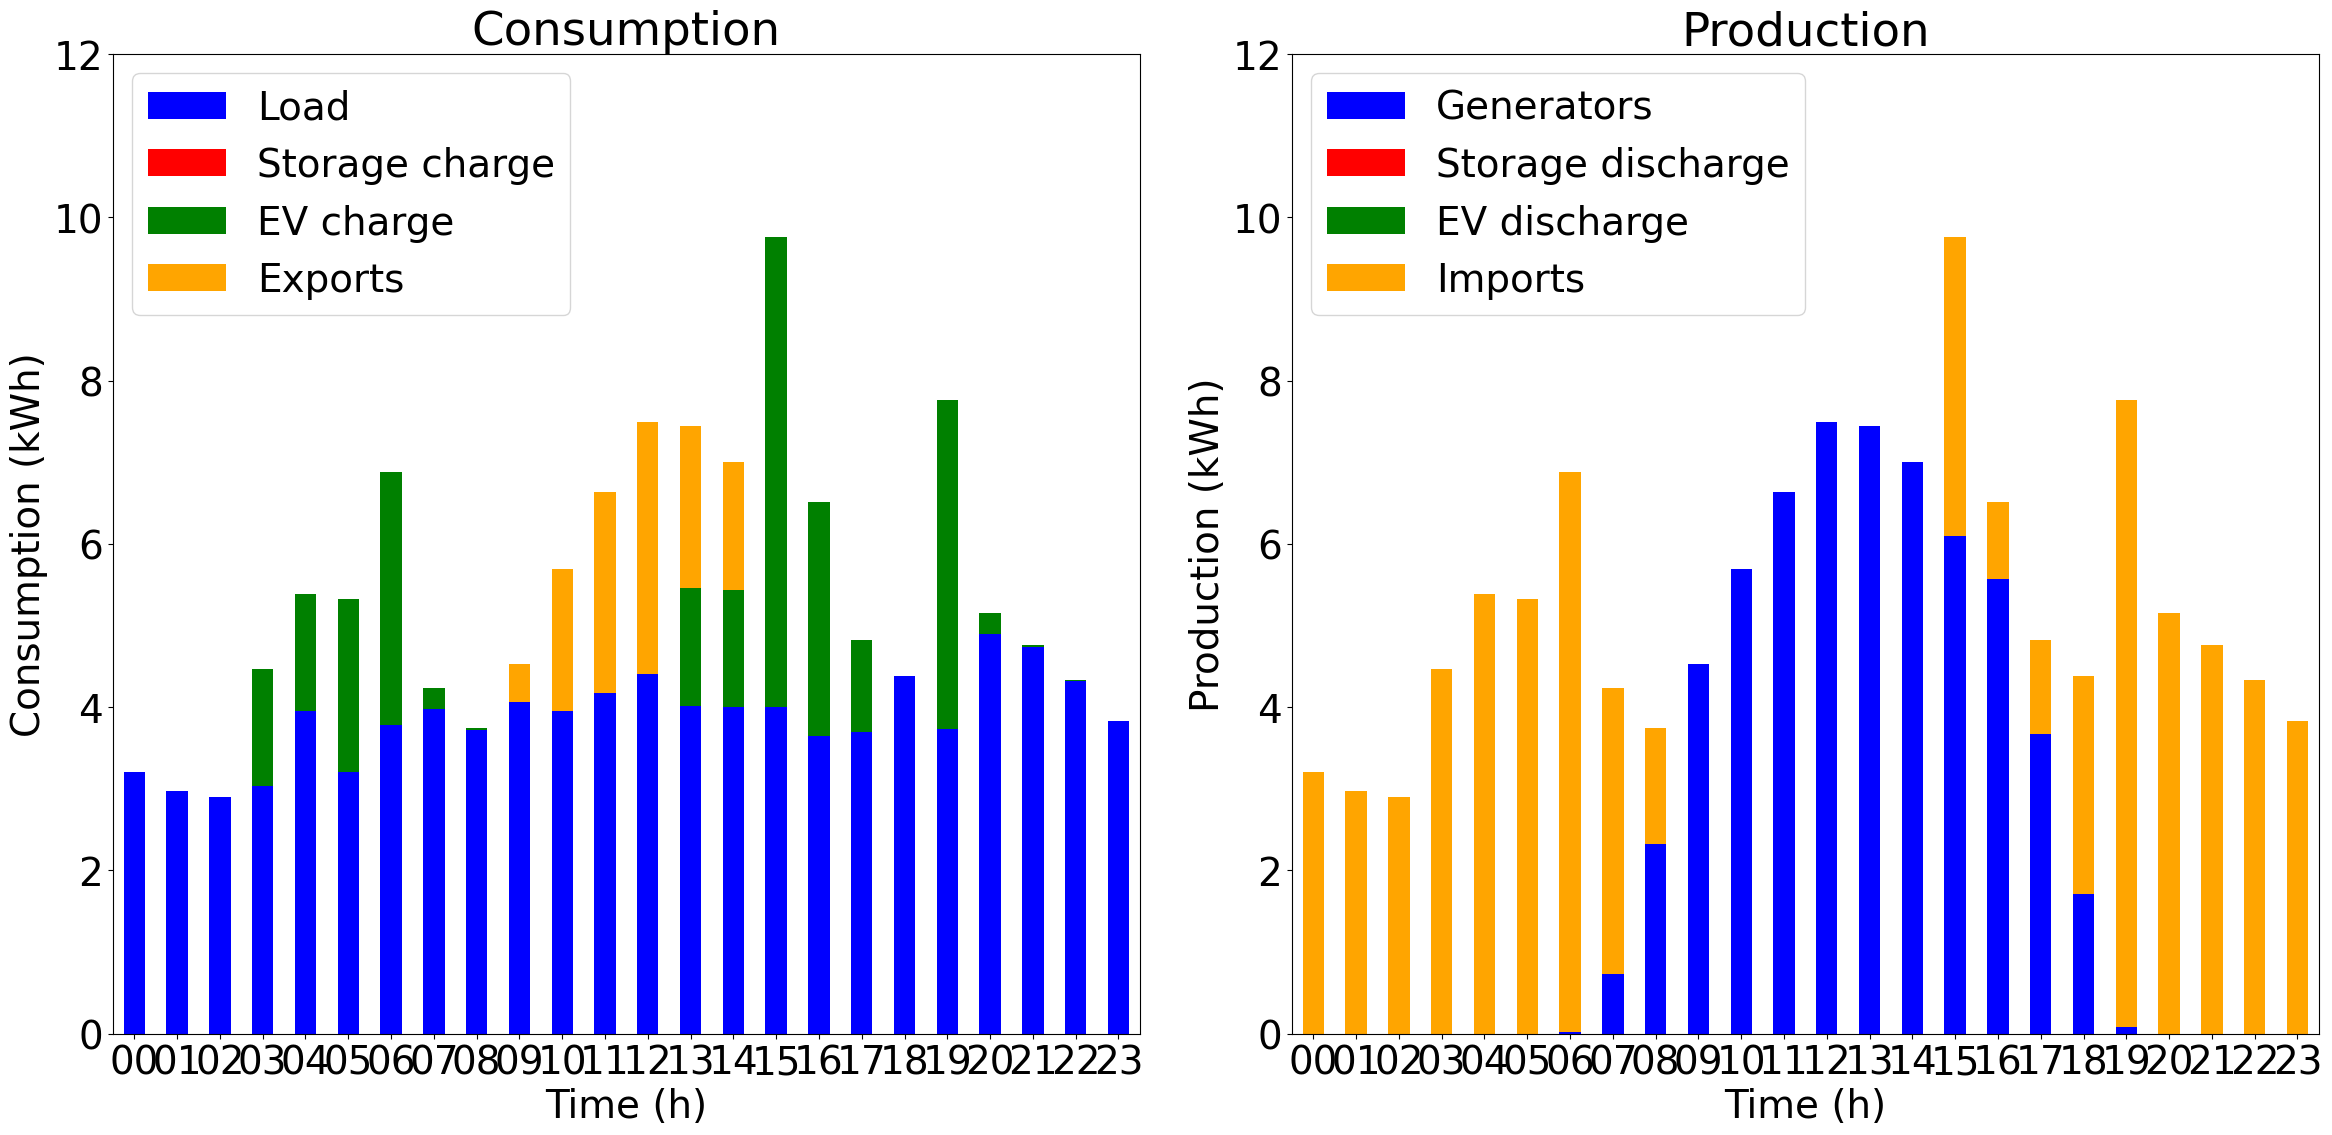

In [21]:
# Plot the stacked bar chart

DAY = '2020-08-15'

# Set the subfigures
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# Consumption data
consumption.loc[DAY].plot(kind='bar', stacked=True, ax=ax[0], color=['blue', 'red', 'green', 'orange'])

# Set the X axis to just have the hours
ax[0].set_xticklabels(consumption.loc[DAY].index.strftime('%H:%M'))

# Plot the aggregator import costs on top, with its own scale
# Create a new axis
#ax2 = ax[0, 0].twinx()
#ax2.plot(seq_consumption.loc[DAY].index, dataset_resources[DAY][-1].import_cost, color='yellow', linestyle='--')

#ax3 = ax[1, 0].twinx()
#ax3.plot(reg_consumption.loc[DAY].index, dataset_resources[DAY][-1].import_cost, color='yellow', linestyle='--')


# Set the scale to go up to 40
ax[0].set_ylim(0, 12)

# Rotate the labels to be horizontal
#ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Set the X axis to just have the hours
ax[0].set_xticklabels(consumption.loc[DAY].index.strftime('%H'))

# Rotate the labels
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Add axis labels
ax[0].set_xlabel('Time (h)')

# Add axis labels
ax[0].set_ylabel('Consumption (kWh)')

# Add title
ax[0].set_title('Consumption')

# Production data
production.loc[DAY].plot(kind='bar', stacked=True, ax=ax[1], color=['blue', 'red', 'green', 'orange', 'purple'])

# Set the scale to go up to 40
ax[1].set_ylim(0, 12)

# Add axis labels
ax[1].set_xlabel('Time (h)')

# Set the X axis to just have the hours
ax[1].set_xticklabels(production.loc[DAY].index.strftime('%H'))

# Rotate the labels to be horizontal
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

# Add axis labels
ax[1].set_ylabel('Production (kWh)')

# Add title
ax[1].set_title('Production')

# Fix the labels for the legend
ax[0].legend(['Load', 'Storage charge', 'EV charge', 'Exports'], loc='upper left')

ax[1].legend(['Generators', 'Storage discharge', 'EV discharge', 'Imports'], loc='upper left')

# Scale the font
plt.rcParams.update({'font.size': 28})

plt.tight_layout()

#plt.savefig('daily_comparison_paper.png', dpi=300)

plt.show()

In [22]:
import copy

def calculate_costs(model_results, model_data):

    datapoint_dict = {}
    overall_dict = pd.DataFrame({}, index=['Costs', 'Profits'])

    for key in model_data.keys():

        current_data = model_results.loc[key].copy(deep=True)
        current_data = current_data[['ren_generator_08',
                                     'ren_generator_06',
                                     'ren_generator_02',
                                     'ren_generator_09',
                                     'ren_generator_13',
                                     'storage_01_discharge',
                                     'storage_02_discharge',
                                     'storage_03_discharge',
                                     'ev_01_discharge',
                                     'ev_02_discharge',
                                     'ev_03_discharge',
                                     'ev_04_discharge',
                                     'ev_05_discharge',
                                     'imports',
                                     'exports']]

        current_data['ren_generator_08'] *= model_data[key][0].cost
        current_data['ren_generator_06'] *= model_data[key][1].cost
        current_data['ren_generator_02'] *= model_data[key][2].cost
        current_data['ren_generator_09'] *= model_data[key][3].cost
        current_data['ren_generator_13'] *= model_data[key][4].cost

        current_data['storage_01_discharge'] *= model_data[key][10].cost_discharge
        current_data['storage_02_discharge'] *= model_data[key][11].cost_discharge
        current_data['storage_03_discharge'] *= model_data[key][12].cost_discharge

        current_data['ev_01_discharge'] *= model_data[key][13].cost_discharge
        current_data['ev_02_discharge'] *= model_data[key][14].cost_discharge
        current_data['ev_03_discharge'] *= model_data[key][15].cost_discharge
        current_data['ev_04_discharge'] *= model_data[key][16].cost_discharge
        current_data['ev_05_discharge'] *= model_data[key][17].cost_discharge

        current_data['imports'] *= model_data[key][-1].import_cost
        current_data['exports'] *= model_data[key][-1].export_cost

        current_data = current_data.round(4)

        datapoint_dict[key] = current_data

        overall_dict[key] = [current_data.sum().iloc[:-1].sum(), current_data.sum().iloc[-1]]

    overall_dict = overall_dict.T

    return overall_dict, datapoint_dict

costs, monthly_costs = calculate_costs(test_data, dataset_resources)

# Sort the index and assign it as a datetime index
costs = costs.sort_index()
costs.index = pd.to_datetime(costs.index)

df_final_costs = pd.DataFrame()
# Sort the index and assign it as a datetime index
for key in monthly_costs.keys():
    monthly_costs[key] = monthly_costs[key].sort_index()
    monthly_costs[key].index = pd.date_range(start='{}-01-01'.format(key), 
                                             periods=len(monthly_costs[key]), freq='H')
    # Only the date, exclude the hours
    #seq_monthly_costs[key].index = pd.to_datetime(seq_monthly_costs[key].index.date)

    # Append the data to the dataframe
    df_final_costs = pd.concat([df_final_costs, monthly_costs[key]])
df_final_costs = df_final_costs.sort_index()

In [45]:
# Load the sequential baseline and the regular baseline

seq_baseline = pd.read_csv('../priority_paper/sequential_costs.csv', index_col=0)

# Load the regular baseline
reg_baseline = pd.read_csv('../priority_paper/regular_costs.csv', index_col=0)

In [53]:
# Group by month

df_costs_grouped = pd.DataFrame({})
df_costs_grouped['costs']  = df_final_costs[list(df_final_costs.columns)[:-1]].sum(axis=1)
df_costs_grouped['seq_baseline'] = seq_baseline[list(seq_baseline.columns)[:-1]].sum(axis=1).values
df_costs_grouped['reg_baseline'] = reg_baseline[list(reg_baseline.columns)[:-1]].sum(axis=1).values
df_costs_grouped = df_costs_grouped.groupby([df_costs_grouped.index.year,
                                             df_costs_grouped.index.month]).sum()

df_export_grouped = pd.DataFrame({})
df_export_grouped['costs'] = df_final_costs['exports']
df_export_grouped['seq_baseline'] = seq_baseline['exports'].values
df_export_grouped['reg_baseline'] = reg_baseline['exports'].values
df_export_grouped = df_export_grouped.groupby([df_export_grouped.index.year,
                                               df_export_grouped.index.month]).sum()

In [56]:
df_costs_grouped['costs'] < df_costs_grouped['reg_baseline']

2019  1     False
      2     False
      3      True
      4      True
      5      True
      6      True
      7      True
      8     False
      9     False
      10     True
      11     True
      12    False
2020  1      True
      2      True
      3      True
      4      True
      5      True
      6      True
      7      True
      8      True
      9      True
      10     True
      11     True
      12     True
2021  1     False
dtype: bool

In [57]:
(df_costs_grouped - df_export_grouped)

costs  seq_baseline  reg_baseline
2019 1   425.156059    406.494084    423.532262
     2   396.981355    391.464180    392.018828
     3   395.814174    385.904927    400.628105
     4   396.915075    387.266115    399.248025
     5   383.970544    373.011491    389.159897
     6   376.149064    363.752207    377.228127
     7   378.342044    370.898074    388.681104
     8   418.625775    406.926376    414.014747
     9   377.749071    363.262044    376.541583
     10  408.543886    401.331634    408.743750
     11   426.35003    414.266495    427.525385
     12  369.731561    362.737217    368.198558
2020 1   350.236001    337.900829    352.725425
     2    412.81518    402.338490    417.037856
     3   391.231889    380.588402    390.667794
     4   309.670399    297.600059    315.973772
     5   294.600286    277.001234    295.429308
     6    315.07137    303.815487    317.192621
     7   382.278231    369.628546    383.283226
     8   378.154155    367.249661    383.367354
     9   400.213134    387.208471    400.974295
     10  382.533257    371.952429    385.066214
     11  406.558392    395.732407    406.324556
     12  411.938111    400.965160    418.536122
2021 1     0.046347      0.046302      0.000000